In [99]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [122]:
d1 = pd.read_csv('200.csv')
d1 = d1.to_numpy()
x1 = d1[:,0] + 22.05
y1 = d1[:, 1] - 0.14

d2 = pd.read_csv('500.csv')
d2 = d2.to_numpy()
x2 = d2[:,0] + 21
y2 = d2[:, 1] - 0.17

d3 = pd.read_csv('1000.csv')
d3 = d3.to_numpy()
x3 = d3[:,0] + 28.7
y3 = d3[:, 1] - 0.16

x = np.linspace(-1, 70, 1000)

In [132]:
fit = lambda x, U, t0: U * np.e**(-x/t0)
p1, c1 = curve_fit(fit, x1[203500:], y1[203500:])
p2, c2 = curve_fit(fit, x2[232500:], y2[232500:])
p3, c3 = curve_fit(fit, x3[203500:], y3[203500:])
print(p1, p2, p3)

[0.28200632 7.95142182] [0.63966185 8.08093942] [1.36404471 8.22232122]
[[ 1.64257209e-10 -4.63144470e-09]
 [-4.63144470e-09  2.59546400e-07]] [[ 5.24235433e-10 -6.59008087e-09]
 [-6.59008087e-09  1.50661205e-07]] [[ 1.01117260e-08 -4.96097044e-08]
 [-4.96097044e-08  3.07887441e-07]]


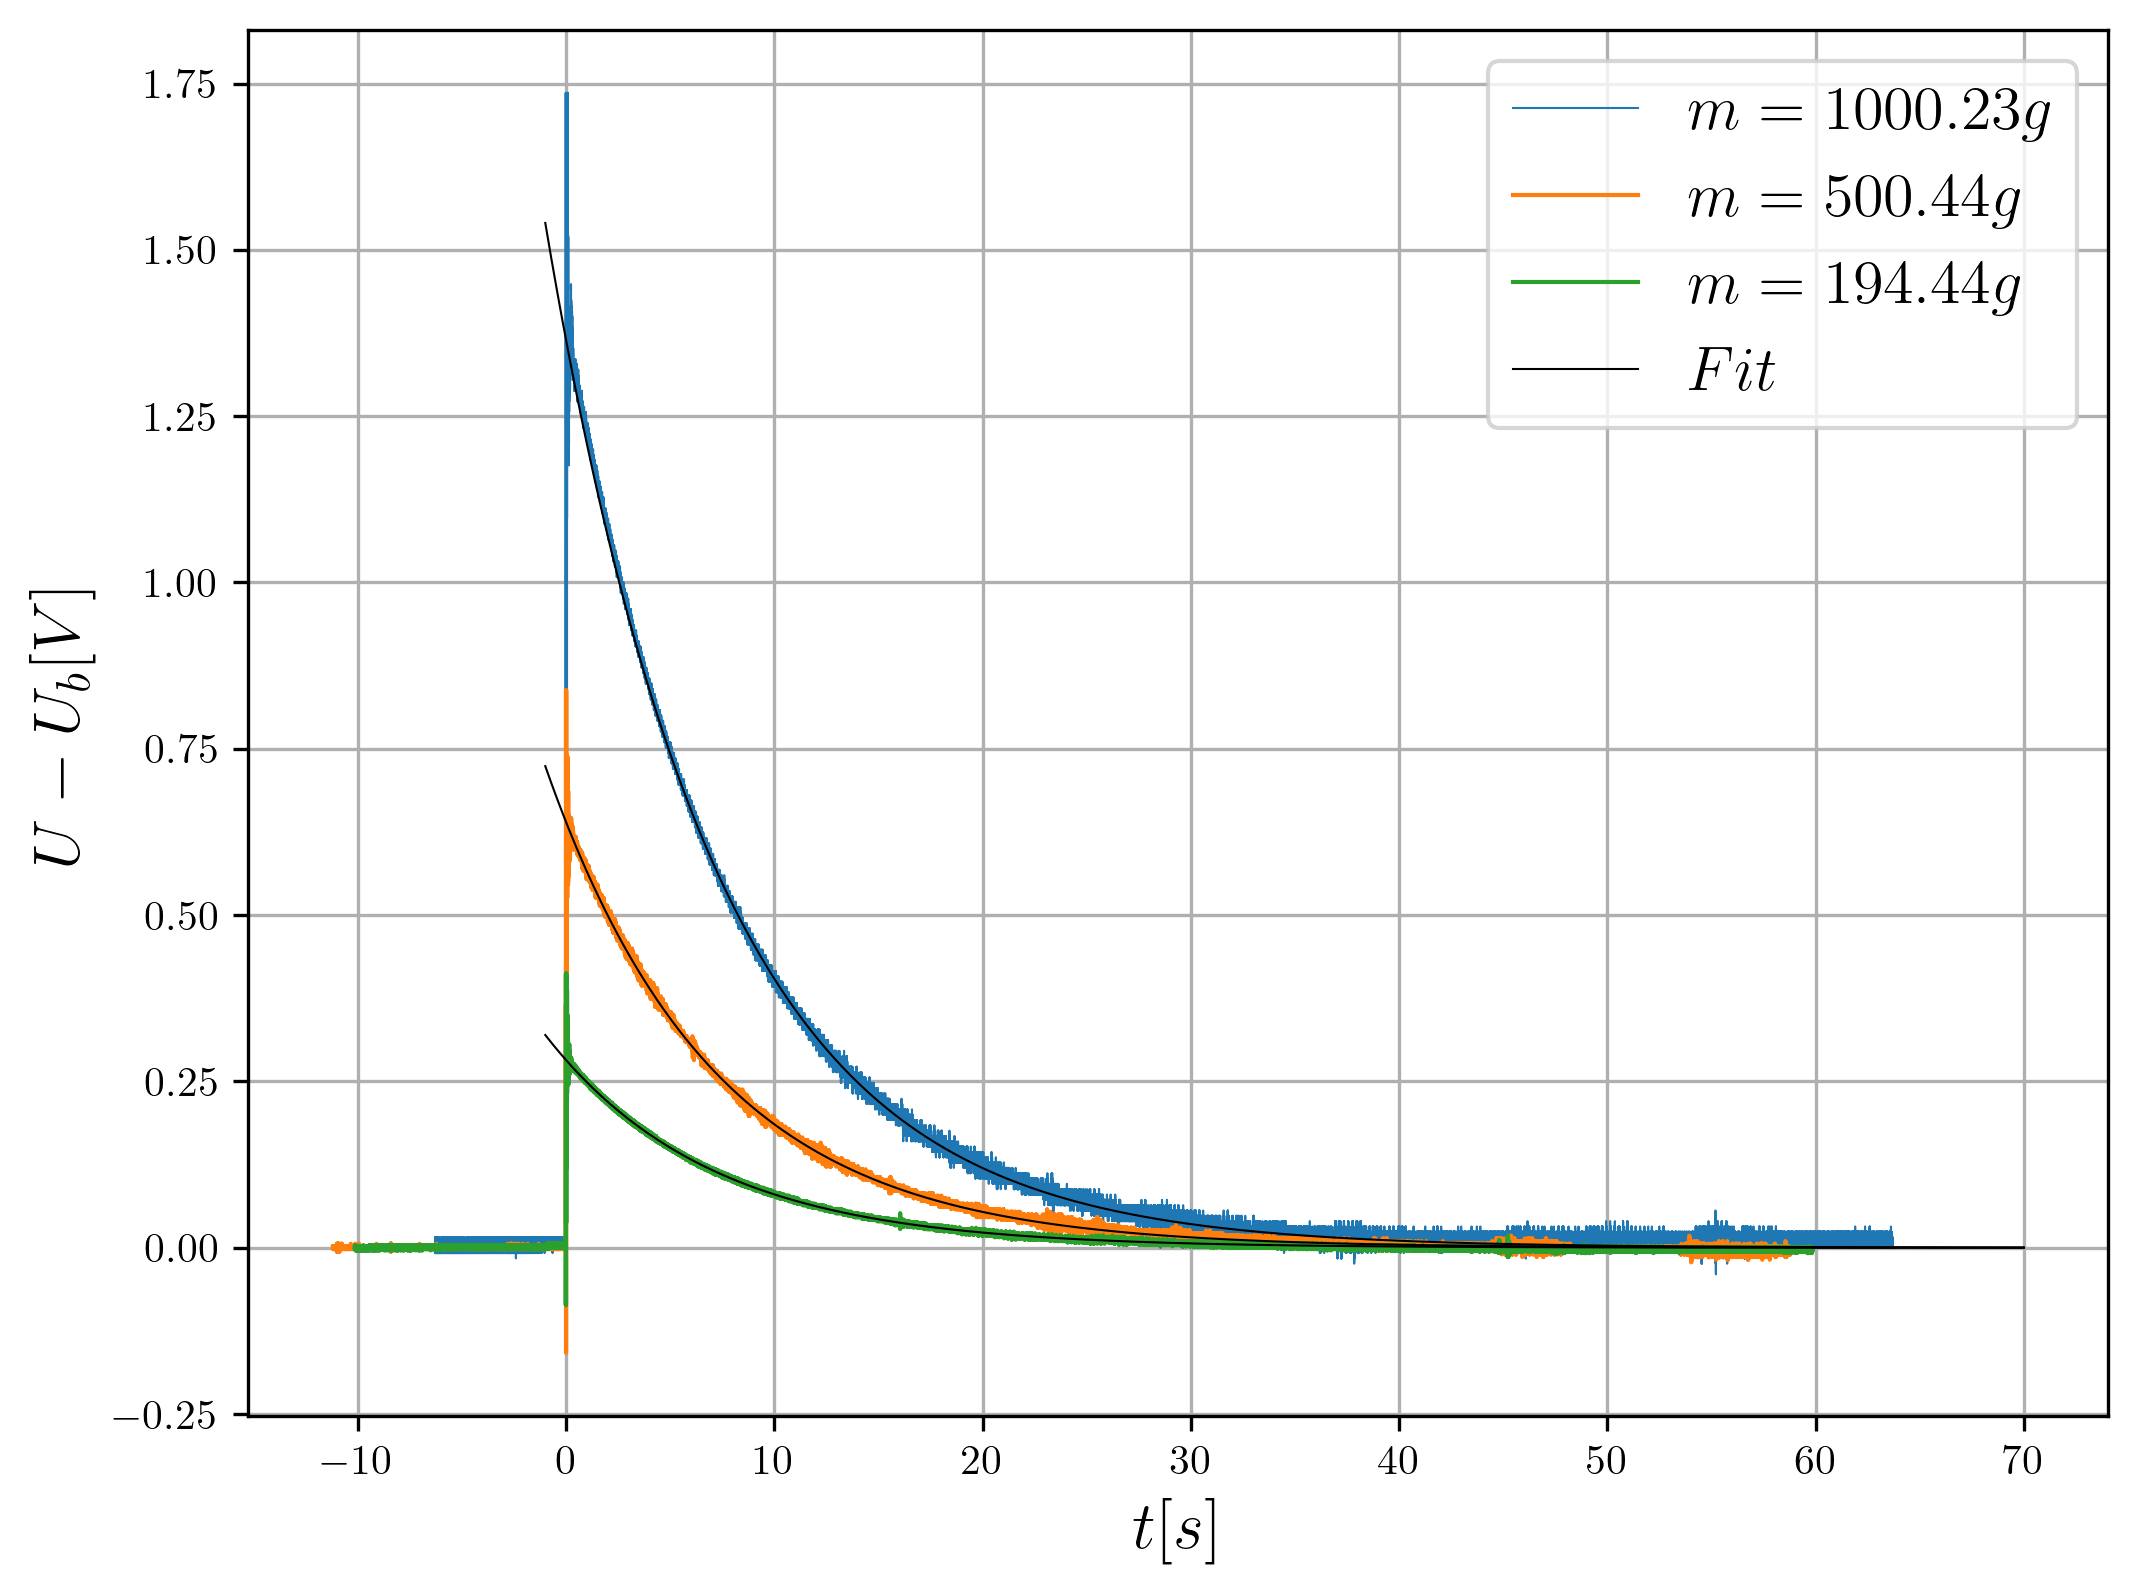

In [129]:
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(8,6), dpi=300)
plt.plot(x3, y3, lw=0.5, label = r"$m = 1000.23g$")
plt.plot(x2, y2, lw=1, label = r"$m = 500.44g$")
plt.plot(x1, y1, lw=1, label = r"$m = 194.44g$")
plt.plot(x, fit(x, p1[0], p1[1]), color="black", lw=0.5, label=r"$Fit$")
plt.plot(x, fit(x, p2[0], p2[1]), color="black", lw=0.5)
plt.plot(x, fit(x, p3[0], p3[1]), color="black", lw=0.5)
plt.xlabel(r"$t[s]$", fontsize=16)
plt.legend(prop={"size":15})
plt.grid(1)
plt.ylabel(r'$U - U_b[V]$', fontsize=16)
plt.savefig("obremenitev.jpg")
plt.show()

In [123]:
d11 = pd.read_csv('200.1D.csv')
d11 = d11.to_numpy()
x11 = d11[:,0] + 22.85
y11 = d11[:, 1] - 0.176

d21 = pd.read_csv('500D.csv')
d21 = d21.to_numpy()
x21 = d21[:,0] + 21.45
y21 = d21[:, 1] - 0.16

d31 = pd.read_csv('1000D.csv')
d31 = d31.to_numpy()
x31 = d31[:,0] + 29.65
y31 = d31[:, 1] - 0.18

In [133]:
fit = lambda x, U, t0: U * np.e**(-x/t0)
p11, c11 = curve_fit(fit, x11[303500:], y11[303500:])
p21, c21 = curve_fit(fit, x21[232500:], y21[232500:])
p31, c31 = curve_fit(fit, x31[203500:], y31[203500:])
print(p11, p21, p31)

[-0.29378671  7.22757705] [-0.72590954  8.0643753 ] [-1.40103999  8.13634974]


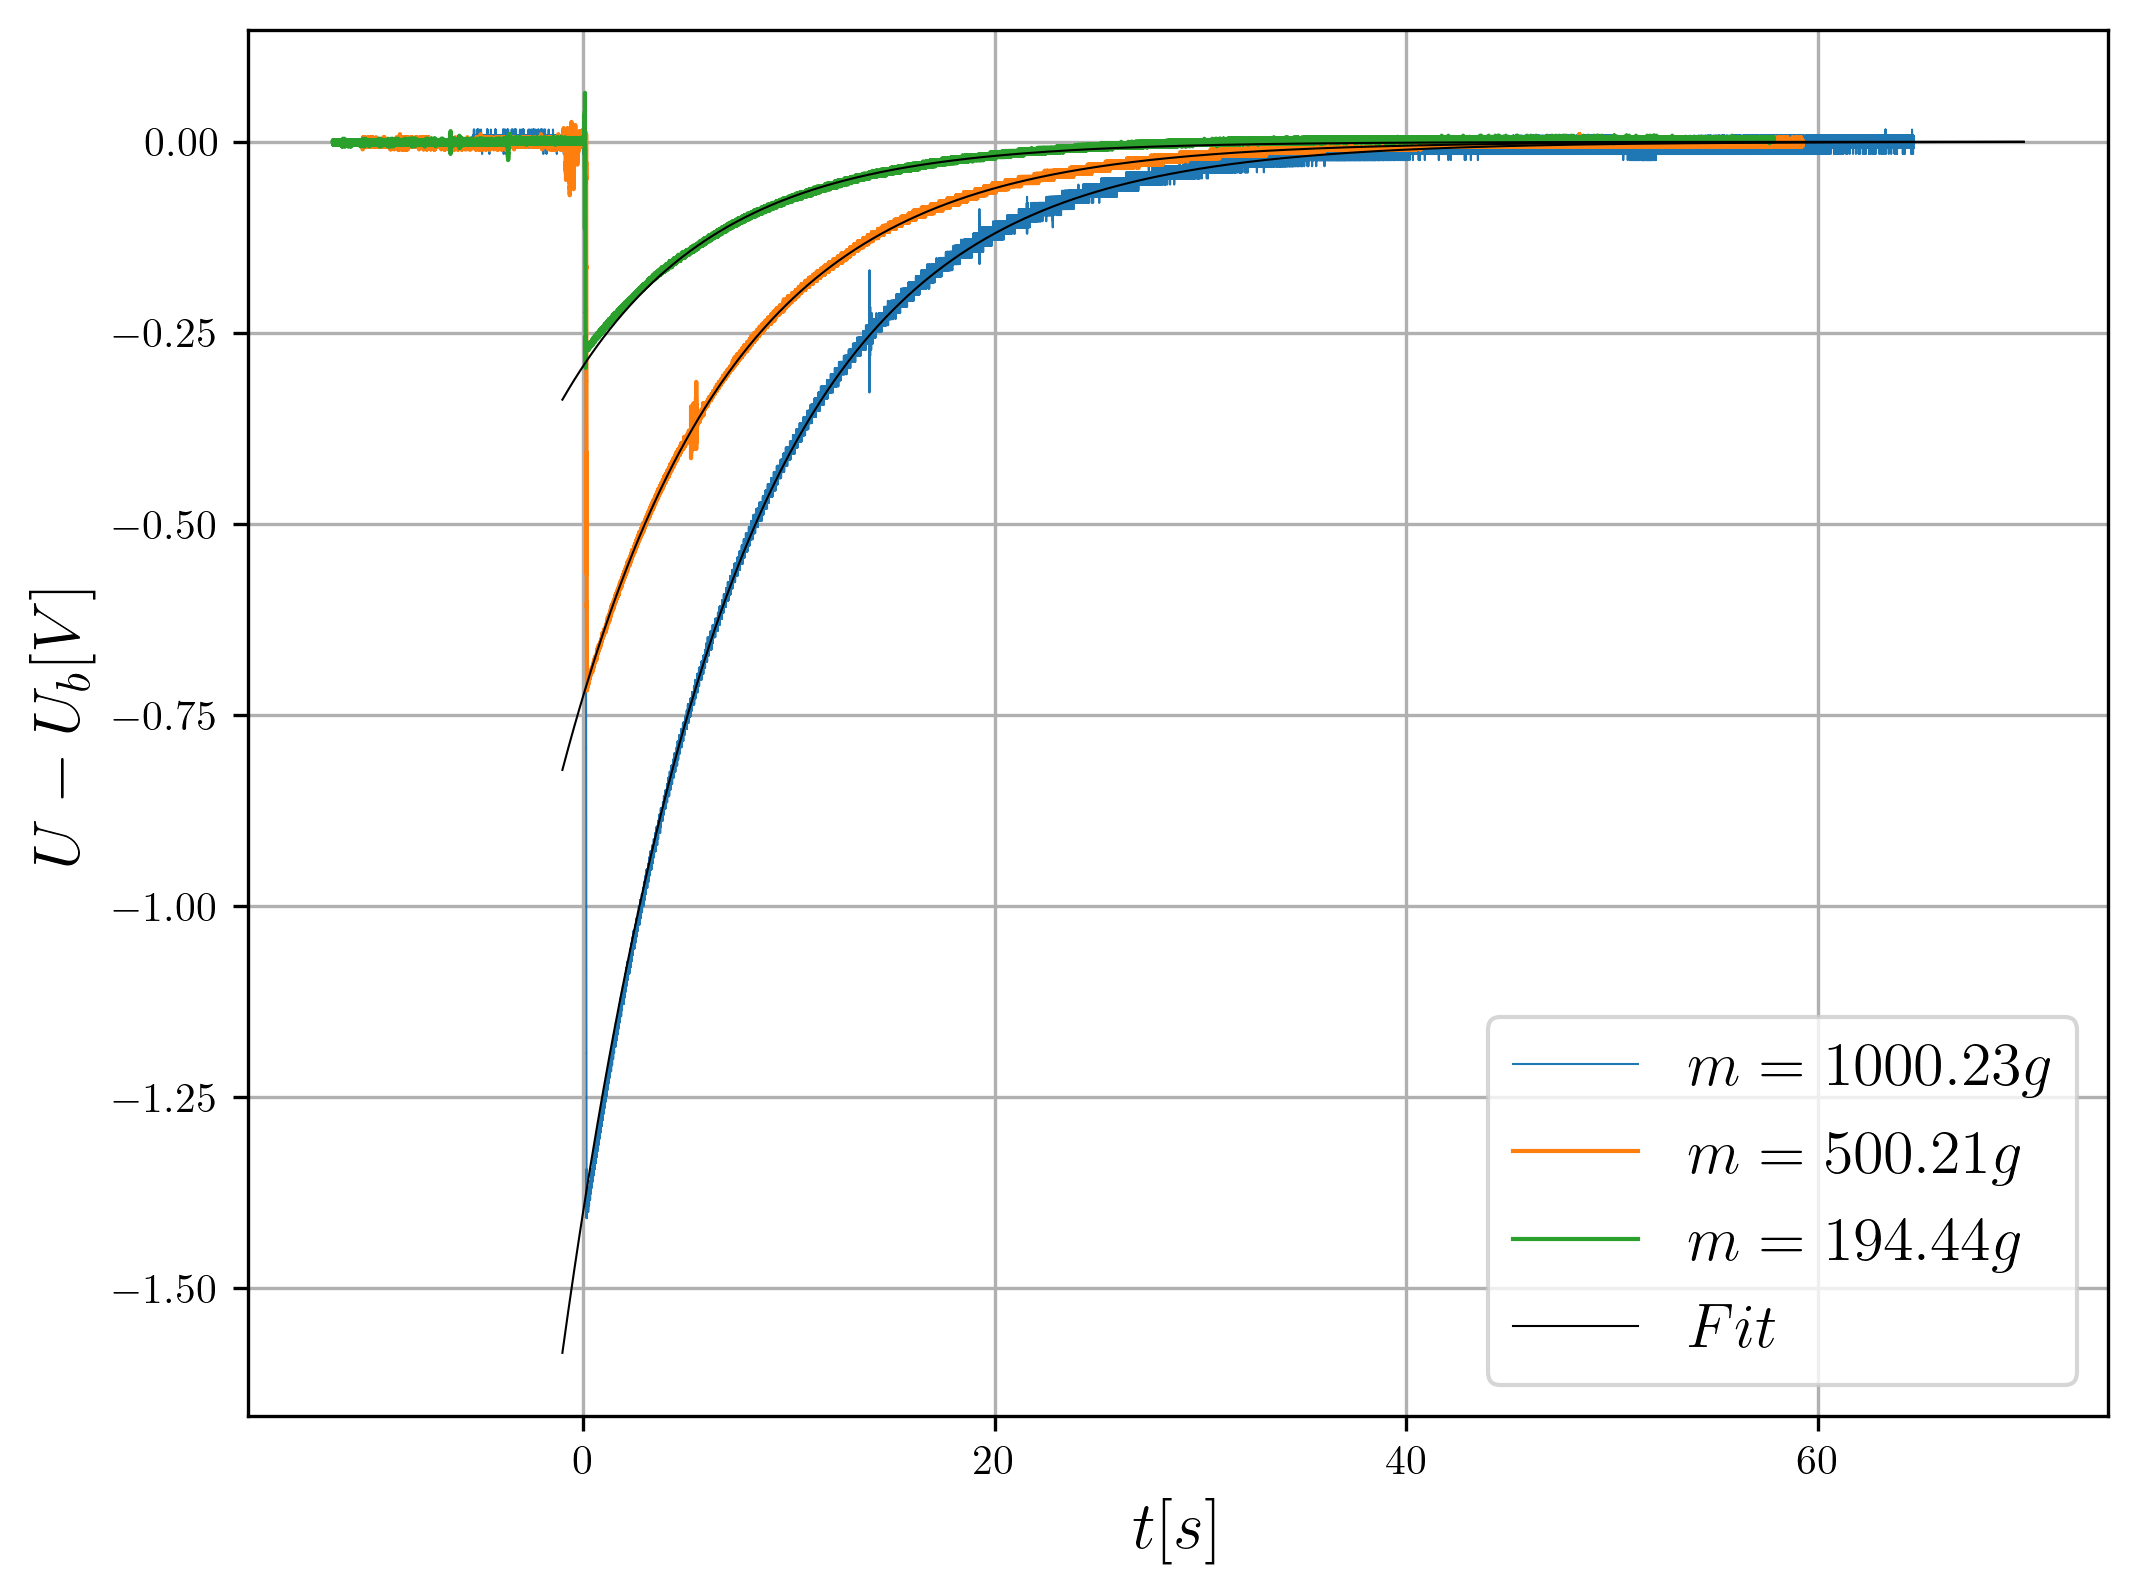

In [130]:
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(8,6), dpi=300)
plt.plot(x31, y31, lw=0.5, label = r"$m = 1000.23g$")
plt.plot(x21, y21, lw=1, label = r"$m = 500.21g$")
plt.plot(x11, y11, lw=1, label = r"$m = 194.44g$")
plt.plot(x, fit(x, p11[0], p11[1]), color="black", lw=0.5, label=r"$Fit$")
plt.plot(x, fit(x, p21[0], p21[1]), color="black", lw=0.5)
plt.plot(x, fit(x, p31[0], p31[1]), color="black", lw=0.5)
plt.xlabel(r"$t[s]$", fontsize=16)
plt.legend(prop={"size":15})
plt.grid(1)
plt.ylabel(r'$U - U_b[V]$', fontsize=16)
plt.savefig("razbremenitev.jpg")
plt.show()

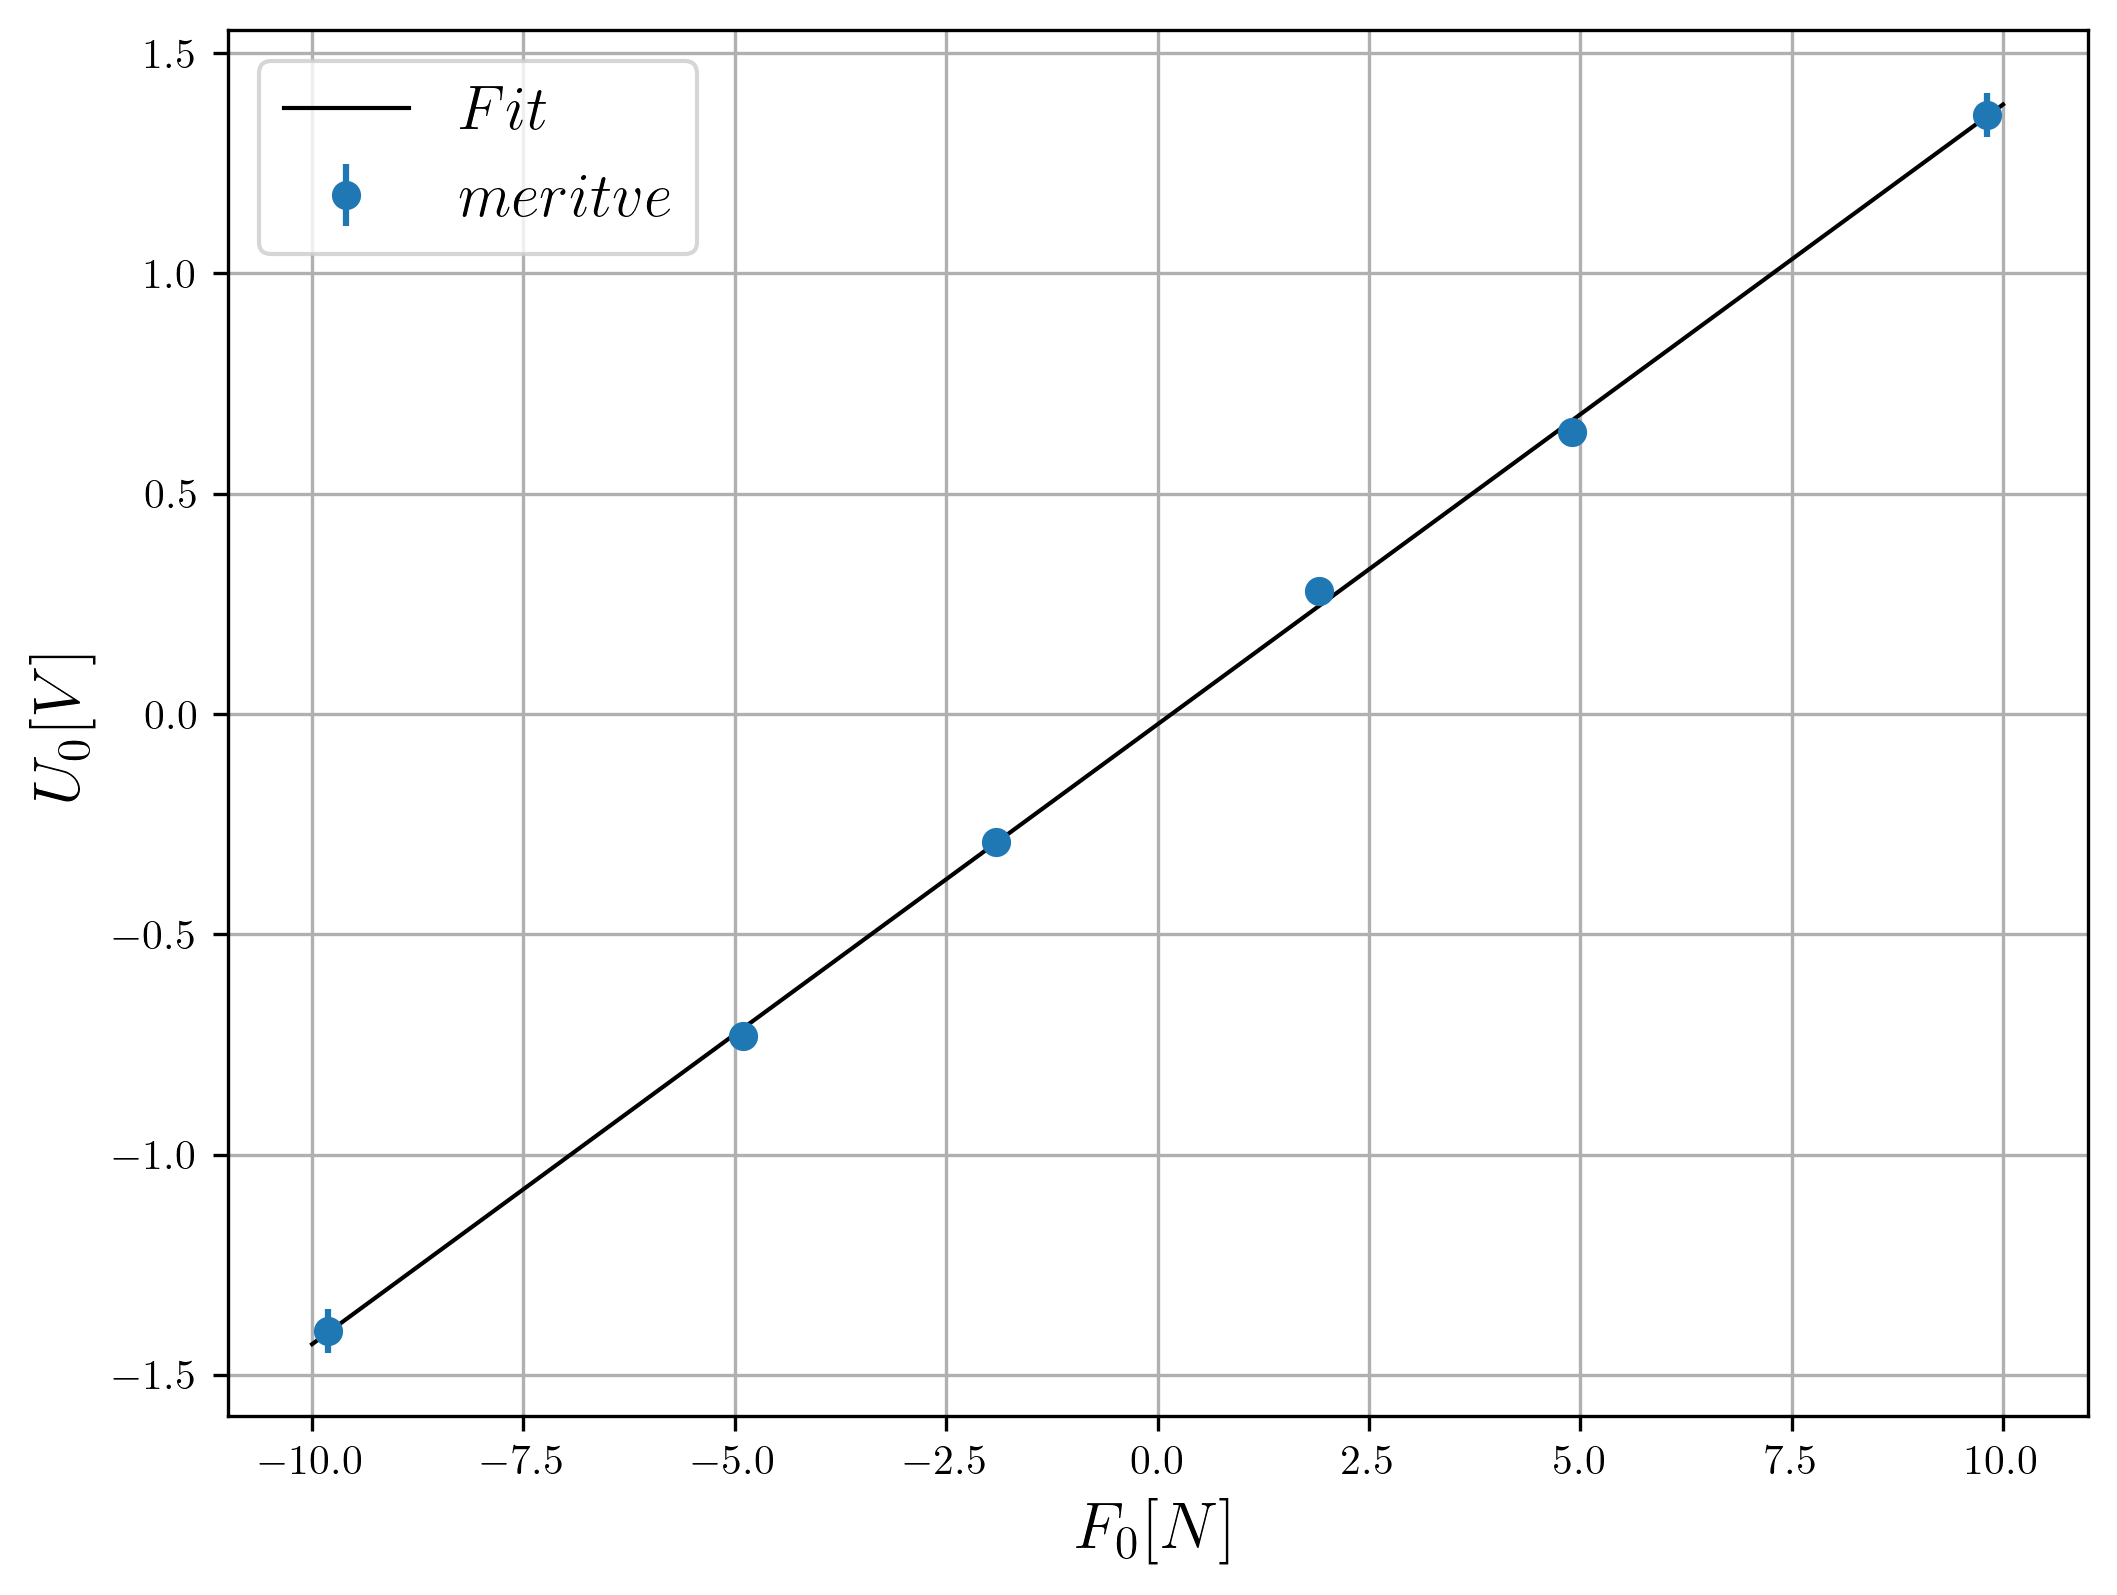

[ 0.14069481 -0.02333333]


In [143]:
fit2 = lambda x, k, n: k * x + n
m=np.array([-1000.23, -500.21, -194.44, 194.44, 500.21, 1000.23])
F = m*9.81/1000
U = np.array([-1.4, -0.73, -0.29, 0.28, 0.64, 1.36])
p4, c4 = curve_fit(fit2, F, U)
x4 = np.linspace(-10, 10, 7)
y4 = [0.05, 0.02, 0.01, 0.01, 0.02, 0.05]

plt.rcParams['text.usetex'] = True
plt.figure(figsize=(8,6), dpi=300)

plt.errorbar(F, U, yerr=y4, fmt="o", label = r"$meritve$")
plt.plot(x4, fit2(x4, p4[0], p4[1]), color="black", lw=1, label=r"$Fit$")

plt.xlabel(r"$F_0[N]$", fontsize=16)
plt.legend(prop={"size":15})
plt.grid(1)
plt.ylabel(r'$U_0[V]$', fontsize=16)
plt.savefig("d.jpg")
plt.show()

print(p4)